In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

In [2]:
customers = pd.read_csv('aml_customers.csv')
transactions = pd.read_csv('aml_transactions.csv')

In [3]:
if 'transaction_date' in transactions.columns:
    transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])

print("Customers dataset preview:")
print(customers.head())
print("\nTransactions dataset preview:")
print(transactions.head())

Customers dataset preview:
   customer_id     region customer_segment risk_rating     occupation  \
0            1  Northeast      Mass Market         Low     Technology   
1            2  Northeast      Mass Market        High      Education   
2            3       West         Affluent         Low    Hospitality   
3            4      South      Mass Market      Medium     Consulting   
4            5  Northeast   Small Business      Medium  Self-Employed   

   avg_monthly_inflow  account_tenure_years  
0            11627.71                     3  
1              100.00                     3  
2            16243.87                     5  
3             4360.58                     2  
4            12211.72                     2  

Transactions dataset preview:
   transaction_id  customer_id       transaction_ts transaction_type  \
0            1576          105  2026-01-01 01:07:00       ACH Credit   
1             671           48  2026-01-01 01:52:00    Card Purchase   
2          

### Question A: What does normal transaction activity look like?

Describe the overall payment population using:

- transaction counts;
- transaction amounts;
- transaction types;
- inflow versus outflow.

Create one visualization summarizing transaction activity.





*Answer is located after cell 7.*

In [4]:
total_transactions_count = len(transactions)
total_transaction_amt = transactions['amount'].sum()
print(f"\nTotal number of transactions: {total_transactions_count}")
print(f"Total transaction amount: {total_transaction_amt}")


Total number of transactions: 3729
Total transaction amount: 8863840.64


In [5]:
type_summary = transactions.groupby(['transaction_type', 'direction']).agg(
    count=('transaction_id', 'count'),
    total_amount=('amount', 'sum'),
    average_amount=('amount', 'mean')
).reset_index()
print("\nTransaction Breakdown by Type:")
print(type_summary)


Transaction Breakdown by Type:
  transaction_type direction  count  total_amount  average_amount
0       ACH Credit        In    559    1573434.31     2814.730429
1        ACH Debit       Out    630    1254322.30     1990.987778
2    Card Purchase       Out   1001    2006495.12     2004.490629
3     Cash Deposit        In    470    1236850.13     2631.596021
4  Cash Withdrawal       Out    407     914998.40     2248.153317
5          Wire In        In    339    1017845.93     3002.495369
6         Wire Out       Out    323     859894.45     2662.211920


In [6]:
inflow_vs_outflow = transactions.groupby('direction').agg(
    transaction_count=('transaction_id', 'count'),
    total_amount=('amount', 'sum'),
    mean_amount=('amount', 'mean'),
    median_amount=('amount', 'median')
).reset_index()

print("\nInflow vs Outflow Breakdown:")
print(inflow_vs_outflow)


Inflow vs Outflow Breakdown:
  direction  transaction_count  total_amount  mean_amount  median_amount
0        In               1368    3828130.37  2798.340914       1972.905
1       Out               2361    5035710.27  2132.871779       1462.110


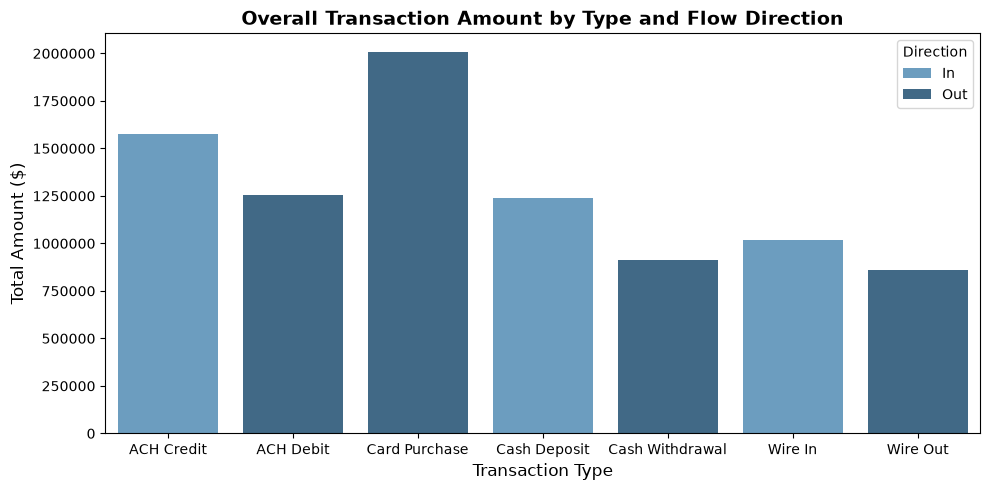

In [7]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=type_summary, 
    x='transaction_type', 
    y='total_amount', 
    hue='direction', 
    palette='Blues_d'
)
plt.title("Overall Transaction Amount by Type and Flow Direction", fontsize=14, fontweight='bold')
plt.xlabel("Transaction Type", fontsize=12)
plt.ylabel("Total Amount ($)", fontsize=12)
plt.legend(title="Direction")
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.savefig("chart1_overall_activity.png", dpi=300)
plt.show()

**What does normal transaction activity look like?**

- Total Transactions: 3,729 transactions
- Total Volume: $8,863,840.64
- Average Transaction Size: $2,377.00
- Median Transaction Size: $1,594.33 (The mean transaction amount exceeds the median, indicating a right-skewed distribution driven by higher-value wire transfers)

Outflows (Debits): Account for **63.3%** of total transactions (**2,361 transactions**) and **56.8%** of dollar value (**$5,035,710.27**), driven heavily by routine card purchases and ACH payments. Average outflow size is **$2,132.87**.

Inflows (Credits): Account for **36.7%** of transaction count (**1,368 transactions**) but represent **43.2%** of dollar value (**$3,828,130.37**). Inflows feature a higher average transaction size (**$2,798.34**), reflecting payroll ACH credits, large cash deposits, and wire transfers.


-----

### Question B: Which customers have notable activity?

Create customer-level metrics and identify accounts that stand out.

Choose at least three indicators, such as:

- unusually high total transaction volume;
- high cash-deposit activity;
- high international wire activity;
- transaction volume substantially above typical monthly inflow;
- rapid incoming/outgoing wire activity.

You do not need machine learning.

You are essentially creating a transaction-monitoring triage analysis.


*Answer located in cell after 23.*

In [8]:
transaction_count_per_customer = transactions.groupby('customer_id').agg(
    transaction_count=('transaction_id', 'count'),
).sort_values(by='transaction_count', ascending=False).reset_index()

transaction_count_per_customer.head()

,customer_id,transaction_count
0,222,26
1,28,22
2,90,22
3,85,22
4,71,22


In [9]:
total_amount = transactions.groupby('customer_id')['amount'].sum().reset_index(name='total_amount').sort_values(by='total_amount', ascending=False)
total_amount.head()

,customer_id,total_amount
74,75,121453.44
243,244,114145.15
59,60,105046.16
113,114,104240.25
238,239,103552.04


In [10]:
deposit_transactions = transactions[transactions['transaction_type'] == 'Cash Deposit']
cash_deposits = deposit_transactions.groupby('customer_id')['amount'].sum().reset_index(name='total_cash_deposit').sort_values(by='total_cash_deposit', ascending=False)
cash_deposits.head()


,customer_id,total_cash_deposit
200,249,39430.80
168,210,38613.29
189,235,31925.92
4,9,29347.30
125,153,25762.49


In [11]:
wires_in = transactions[transactions['transaction_type'] == 'Wire In'].copy()
wires_out = transactions[transactions['transaction_type'] == 'Wire Out'].copy()
wire_pairs = pd.merge(wires_in, wires_out, on='customer_id', suffixes=('_in', '_out'))
wire_pairs['ts_in'] = pd.to_datetime(wire_pairs['transaction_ts_in'])
wire_pairs['ts_out'] = pd.to_datetime(wire_pairs['transaction_ts_out'])

wire_pairs['hours_diff'] = (wire_pairs['ts_out'] - wire_pairs['ts_in']).dt.total_seconds() / 3600.0

In [12]:
rapid_pairs = wire_pairs[(wire_pairs['hours_diff'] > 0) & (wire_pairs['hours_diff'] <= 24)]
rapid_customers = rapid_pairs['customer_id'].unique()

In [13]:
intl_wires = (transactions[(transactions['transaction_type'].isin(['Wire In', 'Wire Out'])) & 
            (transactions['country_code'] != 'US')].groupby('customer_id')['amount'].sum().reset_index(name='total_intl_wires')).sort_values(by='total_intl_wires', ascending=False)
intl_wires.head()


,customer_id,total_intl_wires
34,72,38163.53
88,212,28503.74
95,227,24849.06
87,211,22444.76
31,67,20904.95


In [14]:
cust_summary = customers.merge(total_amount, on='customer_id', how='left')
cust_summary = cust_summary.merge(intl_wires, on='customer_id', how='left')
cust_summary = cust_summary.merge(cash_deposits, on='customer_id', how='left')
cust_summary.head()

,customer_id,region,customer_segment,risk_rating,occupation,avg_monthly_inflow,account_tenure_years,total_amount,total_intl_wires,total_cash_deposit
0,1,Northeast,Mass Market,Low,Technology,11627.71,3,37540.38,20.00,4691.55
1,2,Northeast,Mass Market,High,Education,100.00,3,402.46,126.98,26.98
2,3,West,Affluent,Low,Hospitality,16243.87,5,48111.62,3601.55,NaN
3,4,South,Mass Market,Medium,Consulting,4360.58,2,17204.38,781.16,NaN
4,5,Northeast,Small Business,Medium,Self-Employed,12211.72,2,31767.02,NaN,NaN


In [15]:
cust_summary[['total_amount', 'total_cash_deposit', 'total_intl_wires']] = (
    cust_summary[['total_amount', 'total_cash_deposit', 'total_intl_wires']].fillna(0))
cust_summary.head(10)

,customer_id,region,customer_segment,risk_rating,occupation,avg_monthly_inflow,account_tenure_years,total_amount,total_intl_wires,total_cash_deposit
0,1,Northeast,Mass Market,Low,Technology,11627.71,3,37540.38,20.00,4691.55
1,2,Northeast,Mass Market,High,Education,100.00,3,402.46,126.98,26.98
2,3,West,Affluent,Low,Hospitality,16243.87,5,48111.62,3601.55,0.00
3,4,South,Mass Market,Medium,Consulting,4360.58,2,17204.38,781.16,0.00
4,5,Northeast,Small Business,Medium,Self-Employed,12211.72,2,31767.02,0.00,0.00
5,6,Midwest,Emerging Affluent,High,Technology,9527.93,6,44621.03,4745.62,869.60
6,7,West,Affluent,Medium,Technology,17499.18,2,39479.91,110.07,0.00
7,8,South,Mass Market,Low,Construction,2098.78,4,12070.08,0.00,2397.03
8,9,South,Small Business,Low,Consulting,13604.21,1,67182.04,3331.67,29347.30
9,10,South,Mass Market,Low,Hospitality,4793.79,5,17119.82,2195.27,2638.61


In [16]:
# Deciding on high-risk customers based on thresholds for total amount, cash deposits, and international wires 
# using the 90th percentile as a threshold for each metric.

transaction_amt90 = cust_summary['total_amount'].quantile(0.9)
cash_deposit90 = cust_summary['total_cash_deposit'].quantile(0.9)
intl_wires90 = cust_summary['total_intl_wires'].quantile(0.9)


In [17]:
cust_summary['flag_rapid_wire'] = cust_summary['customer_id'].isin(rapid_customers).astype(int)
cust_summary['flag_high_volume'] = (cust_summary['total_amount'] >= transaction_amt90).astype(int)      
cust_summary['flag_high_cash'] = (cust_summary['total_cash_deposit'] >= cash_deposit90).astype(int)   
cust_summary['flag_high_intl_wire'] = (cust_summary['total_intl_wires'] >= intl_wires90).astype(int)
cust_summary[['customer_id', 'risk_rating', 'flag_high_volume', 'flag_high_cash', 'flag_high_intl_wire', 'flag_rapid_wire']].head(10)

,customer_id,risk_rating,flag_high_volume,flag_high_cash,flag_high_intl_wire,flag_rapid_wire
0,1,Low,0,0,0,0
1,2,High,0,0,0,0
2,3,Low,0,0,0,0
3,4,Medium,0,0,0,0
4,5,Medium,0,0,0,0
5,6,High,0,0,0,0
6,7,Medium,0,0,0,0
7,8,Low,0,0,0,0
8,9,Low,0,1,0,0
9,10,Low,0,0,0,0


In [18]:
cust_flagged = cust_summary[(cust_summary['flag_high_volume'] == 1) | (cust_summary['flag_high_cash'] == 1) |
                            (cust_summary['flag_high_intl_wire'] == 1) | 
                            (cust_summary['flag_rapid_wire'] == 1)]
cust_flagged.head(10)


,customer_id,region,customer_segment,risk_rating,occupation,avg_monthly_inflow,account_tenure_years,total_amount,total_intl_wires,total_cash_deposit,flag_rapid_wire,flag_high_volume,flag_high_cash,flag_high_intl_wire
8,9,South,Small Business,Low,Consulting,13604.21,1,67182.04,3331.67,29347.30,0,0,1,0
11,12,Midwest,Affluent,Medium,Retail,19901.15,7,100876.63,3141.39,16678.25,0,1,1,0
12,13,Midwest,Mass Market,Low,Retail,4397.15,4,27624.87,2876.19,14787.24,0,0,1,0
17,18,Northeast,Mass Market,High,Technology,5372.20,1,26264.72,10142.94,0.00,0,0,0,1
21,22,South,Mass Market,Low,Retail,13218.52,6,74418.95,6225.20,20.00,0,1,0,0
22,23,South,Emerging Affluent,Medium,Retail,15384.31,4,100512.00,17043.78,11330.24,1,1,0,1
31,32,Midwest,Affluent,Low,Self-Employed,19908.55,7,64862.78,4922.45,18246.68,0,0,1,0
36,37,South,Mass Market,Low,Education,7035.77,7,45477.83,0.00,16674.86,0,0,1,0
44,45,West,Mass Market,Low,Education,18446.40,7,95591.12,7741.93,5818.82,1,1,0,1
47,48,South,Small Business,Low,Technology,14920.41,7,54546.50,0.00,18449.55,0,0,1,0


In [19]:
cust_flagged_summary = cust_flagged.agg(
    {'flag_high_volume': 'sum', 'flag_high_cash': 'sum', 'flag_high_intl_wire': 'sum', 'flag_rapid_wire': 'sum'}
)
cust_flagged_summary

flag_high_volume       25
flag_high_cash         25
flag_high_intl_wire    25
flag_rapid_wire        11
dtype: int64

In [20]:
# High Volume Flagged Customers
cust_flagged[cust_flagged['flag_high_volume'] == 1][['customer_id']]


,customer_id
11,12
21,22
22,23
44,45
59,60
64,65
70,71
71,72
74,75
83,84


In [21]:
# High Cash Deposit Flagged Customers
cust_flagged[cust_flagged['flag_high_cash'] == 1][['customer_id']]

,customer_id
8,9
11,12
12,13
31,32
36,37
47,48
63,64
66,67
83,84
89,90


In [22]:
# High International Wire Flagged Customers
cust_flagged[cust_flagged['flag_high_intl_wire'] == 1][['customer_id']]

,customer_id
17,18
22,23
44,45
59,60
66,67
71,72
75,76
77,78
83,84
113,114


In [23]:
# Rapid Wire Flagged Customers
cust_flagged[cust_flagged['flag_rapid_wire'] == 1][['customer_id']]

,customer_id
22,23
44,45
59,60
81,82
146,147
150,151
167,168
180,181
211,212
217,218




My chosen flags:
- Transaction Volume: Customers whose transaction totals are in the top 10%.
- Cash Deposits: Customers whose total cash deposits are in the top 10%.
- International Wires: Customers whose non-US incoming and outgoing wires are in the top 10%.
- Rapid Wires: Outgoing wire occurring within 24 hours after an incoming wire.

Thresholds:

- Total transaction amount: $72,661.39
- Cash deposits: $13,894.84
- International wires: $6,312.81
- Rapid wires: 24 hours



Population Breakdown by Total Triggered Flags

- All 4: 0
- 3 Flags Triggered: **6 customers (Customers 23, 45, 60, 84, 114, 151)**
- 2 Flags Triggered: **15 customers**
- 1 Flag Triggered: **38 customers**
- 0 Flags Triggered: **191 customers**


-----

### Question C: Build a review-priority score

This is the main business task.

Create a simple scoring framework using the indicators you calculated.

Your responsibility is to define a simple, explainable score and rank customers into something like:

Lower review priority
Medium review priority
Higher review priority

Then select approximately 5–10 customers you would recommend for analyst review.

For each one, explain briefly:

What caused this customer to rank highly?


*Answered after cell 27*



In [24]:
cust_summary['flag_high_risk_rating'] = (cust_summary['risk_rating'] == 'High').astype(int)
cust_summary['review_score'] = (
    cust_summary['flag_high_cash'] +
    cust_summary['flag_high_intl_wire'] +
    cust_summary['flag_high_volume'] +
    cust_summary['flag_rapid_wire'] +
    cust_summary['flag_high_risk_rating']
)

In [25]:
def assign_priority_tier(score):
    if score >= 3:
        return 'Higher review priority'
    elif score in [1, 2]:
        return 'Medium review priority'
    else:
        return 'Lower review priority'

cust_summary['priority_tier'] = cust_summary['review_score'].apply(assign_priority_tier)

In [26]:
print(cust_summary['priority_tier'].value_counts())

priority_tier
Lower review priority     171
Medium review priority     72
Higher review priority      7
Name: count, dtype: int64


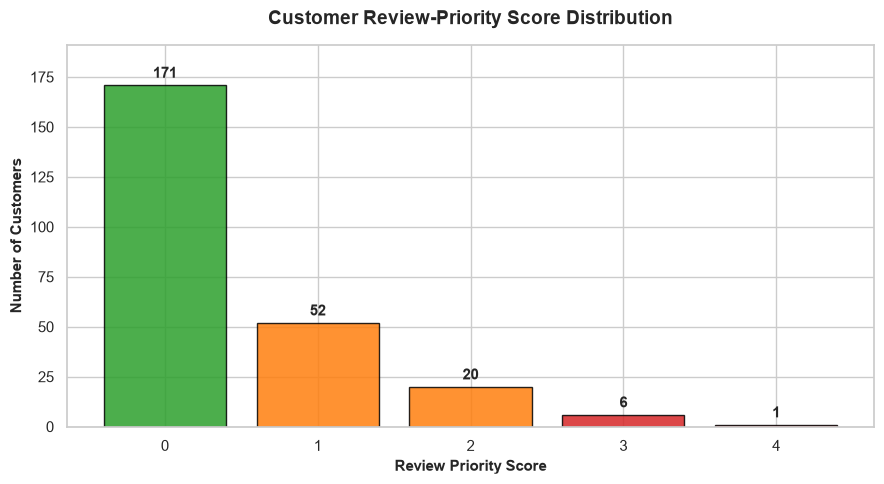

In [27]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 5))

score_counts = cust_summary['review_score'].value_counts().sort_index()
bar_colors = ['#2ca02c', '#ff7f0e', '#ff7f0e', '#d62728', '#d62728']

bars = plt.bar(
    score_counts.index.astype(str), 
    score_counts.values, 
    color=bar_colors[:len(score_counts)], 
    edgecolor='black', 
    alpha=0.85
)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0, 
        yval + 2, 
        f"{yval}", 
        ha='center', 
        va='bottom', 
        fontweight='bold', 
        fontsize=11
    )

plt.title('Customer Review-Priority Score Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Review Priority Score', fontweight='bold', fontsize=11)
plt.ylabel('Number of Customers', fontweight='bold', fontsize=11)
plt.ylim(0, max(score_counts.values) + 20)
plt.tight_layout()

plt.savefig('chart2_score_distribution.png', dpi=300)
plt.show()

The following are the customers chosen for review priority with their respective reasons.

| Customer | Score | Reasons for analyst review |
|---|---:|---|
| 84 | 4 | Elevated total volume, cash deposits, international wires, and existing High risk rating |
| 23 | 3 | Elevated total volume, international wires, and rapid wire activity |
| 45 | 3 | Elevated total volume, international wires, and rapid wire activity |
| 60 | 3 | Elevated total volume, international wires, and rapid wire activity |
| 67 | 3 | Elevated cash deposits, international wires, and existing High risk rating |
| 114 | 3 | Elevated total volume, cash deposits, and international wires |
| 151 | 3 | Elevated total volume, international wires, and rapid wire activity |

----

Part 3 — Case review table

Inside the notebook, create a final table containing your highest-priority accounts.

Recommended fields:

Customer| Risk Rating |Cash Activity |Intl. Wires |Rapid Movement |Review Score



You may include additional useful fields.

This table is one of the most important pieces of the project because it demonstrates the transition from:

data analysis

to

investigative prioritization

In [28]:

case_review = (
    cust_summary.loc[
        cust_summary["priority_tier"] == "Higher review priority"
    ]
    .sort_values(
        ["review_score", "customer_id"],
        ascending=[False, True]
    )
    .copy()
)


def explain_review(row):
    reasons = []

    if row["flag_high_volume"]:
        reasons.append("elevated total transaction volume")
    if row["flag_high_cash"]:
        reasons.append("elevated cash deposits")
    if row["flag_high_intl_wire"]:
        reasons.append("elevated international wire activity")
    if row["flag_rapid_wire"]:
        reasons.append("outgoing wire within 24 hours after an incoming wire")
    if row["flag_high_risk_rating"]:
        reasons.append("existing High risk rating")

    return "; ".join(reasons)

case_review["review_reason"] = case_review.apply(explain_review, axis=1)

case_review_table = case_review[
    [
        "customer_id",
        "risk_rating",
        "total_amount",
        "total_cash_deposit",
        "total_intl_wires",
        "flag_rapid_wire",
        "review_score",
        "priority_tier",
        "review_reason",
    ]
].rename(
    columns={
        "customer_id": "Customer",
        "risk_rating": "Existing Risk Rating",
        "total_amount": "Total Transaction Amount ($)",
        "total_cash_deposit": "Cash Deposits ($)",
        "total_intl_wires": "International Wires ($)",
        "flag_rapid_wire": "Rapid Movement",
        "review_score": "Review Score",
        "priority_tier": "Review Priority",
        "review_reason": "Reason for Review",
    }
)

case_review_table["Rapid Movement"] = (
    case_review_table["Rapid Movement"].map({1: "Yes", 0: "No"})
)

print(
    f"Recommended for analyst review: {len(case_review_table)} customers\n"
    "Period: January–June 2026. Amounts are totals over this period.\n"
    "These indicators prioritize review; they do not establish wrongdoing."
)

display(
    case_review_table.style
    .format({
        "Total Transaction Amount ($)": "${:,.2f}",
        "Cash Deposits ($)": "${:,.2f}",
        "International Wires ($)": "${:,.2f}",
    })
    .hide(axis="index")
    .set_properties(**{
        "text-align": "left",
        "white-space": "normal",
    })
)

Recommended for analyst review: 7 customers
Period: January–June 2026. Amounts are totals over this period.
These indicators prioritize review; they do not establish wrongdoing.


Customer,Existing Risk Rating,Total Transaction Amount ($),Cash Deposits ($),International Wires ($),Rapid Movement,Review Score,Review Priority,Reason for Review
84,High,"$77,277.99","$17,368.04","$7,970.95",No,4,Higher review priority,elevated total transaction volume; elevated cash deposits; elevated international wire activity; existing High risk rating
23,Medium,"$100,512.00","$11,330.24","$17,043.78",Yes,3,Higher review priority,elevated total transaction volume; elevated international wire activity; outgoing wire within 24 hours after an incoming wire
45,Low,"$95,591.12","$5,818.82","$7,741.93",Yes,3,Higher review priority,elevated total transaction volume; elevated international wire activity; outgoing wire within 24 hours after an incoming wire
60,Medium,"$105,046.16","$6,466.02","$18,375.28",Yes,3,Higher review priority,elevated total transaction volume; elevated international wire activity; outgoing wire within 24 hours after an incoming wire
67,High,"$56,287.35","$16,433.48","$20,904.95",No,3,Higher review priority,elevated cash deposits; elevated international wire activity; existing High risk rating
114,Low,"$104,240.25","$15,173.23","$10,349.70",No,3,Higher review priority,elevated total transaction volume; elevated cash deposits; elevated international wire activity
151,Low,"$79,892.96","$8,952.79","$14,437.56",Yes,3,Higher review priority,elevated total transaction volume; elevated international wire activity; outgoing wire within 24 hours after an incoming wire
